## Model Selection, Cross-Validation


An algorithm is good if it can makes prediction.

* **Training** data are used for the actual fit
* **Validation** data are used to optimize the hyoerparameters of the algorithm, needed if we want to choose between different algorithms (Hyperparameters refers to parameters outside the chosen model, it could be the model itself)
* **Test** data are used at the very end to evaluate the overall performance.

**NB** There are some obvious issues here. Splitting the data not only does leave us less data for training (and we know less data is bad for machine learning!), but it also means that it matters which objects are in each of the training, validation, and test sets. We can solve both of these problems with **cross validation**. An example is K-fold. Cross validation allows to **determine the hyperparameters** of each algorithm (the number of bins in an histogram, the bandwidth of a KDE, the number of modes in Gaussian Mixtures)

This divsion will become crucial when we'll look at deep learning stategies. The reason is that deep learning can behave like a black box which is hard to control. Testing and validating is essentially the only way to make sure one is doing something meaninful.

The gerco of ML people is to $\textit{train parameters}$ vs $\textit{tune hyperparameters}$



### K-fold

It's a combination of train and validation operation. No prediction is performed. For each hyperpar an entire K-fold algorithm is run. At each fold we have a score. Score average gives a robust estimate of the model performance. Perform k-fold for n values of hyperparameters using GridSearchCV. 

## Clustering


### 1. K-Means: La spartizione del territorio
Il **K-Means** è un algoritmo di partizionamento guidato dai centroidi che mira a suddividere geometricamente lo spazio in un numero $K$ di regioni distinte, stabilito a priori dall'utente. Il processo inizia posizionando casualmente $K$ centroidi provvisori; successivamente, ogni punto del dataset viene associato al centroide più vicino e la posizione di ciascun centroide viene aggiornata calcolando il baricentro geografico (la media aritmetica) di tutti i punti assegnati a quel gruppo. Questo ciclo di assegnazione e aggiornamento si ripete in modo iterativo fino alla convergenza, minimizzando matematicamente la somma delle distanze al quadrato tra i punti e i rispettivi centri (la cosiddetta inerzia o WCSS).

### 2. Mean Shift: La salita verso la cima
Il **Mean Shift** è un algoritmo probabilistico basato sulla densità che non richiede di specificare il numero di cluster in anticipo, ma lo individua autonomamente. Immaginando il dataset come una mappa topografica in cui le zone ad alta densità rappresentano le cime delle montagne, l'algoritmo definisce una finestra sferica di raggio $h$ (chiamata *bandwidth*) attorno a ogni punto e calcola costantemente il baricentro locale dei punti che vi cadono dentro. Muovendo in modo iterativo ogni punto nella direzione di massima salita (definita dal *Mean Shift vector*), tutti gli elementi che terminano la loro "scalata" sulla stessa identica vetta (il *modo* della distribuzione) vengono raggruppati nello stesso cluster.

### 3. Confronto tra i due approcci
Nel **confronto diretto**, la differenza fondamentale risiede nell'approccio geometrico e nella sensibilità agli outlier: mentre il K-Means impone una rigida divisione dello spazio basata su forme circolari o sferiche ed è estremamente vulnerabile agli outlier (che possono trascinare e distorcere la posizione dei centroidi globali), il Mean Shift è in grado di adattarsi a distribuzioni di densità di forma arbitraria. Tuttavia, questa flessibilità rende il Mean Shift estremamente dipendente dal parametro della *bandwidth* $h$ (la cui scelta errata può portare a un'eccessiva frammentazione in presenza di outlier isolati, che vengono scambiati per piccoli cluster indipendenti) ed è computazionalmente molto più oneroso da calcolare su dataset di grandi dimensioni rispetto alla rapidità del K-Means.

###  K-means

Guess centroid, the algorithm optimize the loss function (distances), the number of cluster is an hyperparameter

### Mean Shift


After KDE, move datapoint in the direction of the gradient to find the members of each cluster as the place (peak) in which the end up after N shifts
Tends to overestimate the number of peaks (clusters)

Mean-shift clustering works by finding the modes in a kernel density estimator of the distribution. Clustering is achieved by the mean-shift algorithm:

The KDE of the dataset is computed.
This allows the gradient of the distribution to be calculated. Easy to do since it's a bunch of overlapping Gaussians.
Each data point is shifted in the direction of increasing gradient, which drives the points toward the modes.
This process is iterated until all points have converged with clusters of other points at each of several distinct modes.
Each data point is then associated with a cluster of other points.


### Spectral Clustering 

Lo usa lui, è semisupervise. 

## Gamma Ray Bursts

Let's try different clustering method to esplore the nature of GRB, starting from how long they last and at which redshifts. We want to answer these questions:
* Does the distribution contain different sub-populations? How many?
* What's the threshold between the classes?
* If you try two clustering methods, do you get more or less the same?
* How do methods respond to outliers?
* What variable(s) shows the multi-modality more evidently?
* Are all GRBs equally likely to be observed?

Answers:
* Depends on the algorithm of choice, 2 appers the best choice after computing the score both with GMM and Kmeans.
* Kmeans media distanza centroidi, MeanShift zone a bassa densità (silhouette = 0), GMM equal probability points.
* Tried Kmeans, GMM and MeansShift. The last one is far worst, more subject to outliers, tend to prefer high number of clusters.
* Kmeans is weak to outliers resulting in shifted centroids, Meanshift is weak to outliers resulting in fake isolated clusters.
* In this analysis T90 due to the physical double nature of GRB, long and short.
* Malmquist selection effect

### Data visualization

Dati caricati con successo! Shape: (15, 9170)


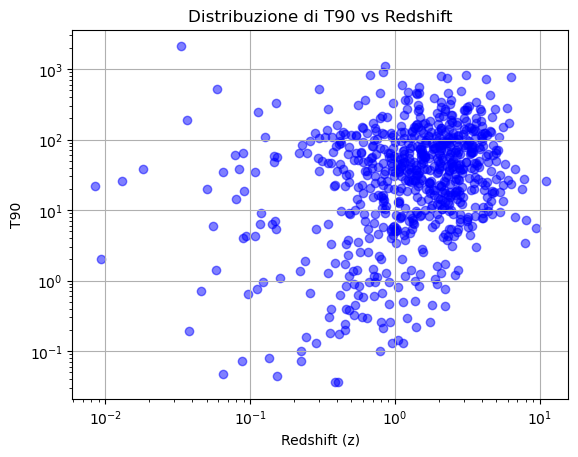

In [4]:
import numpy as np
import requests
import io

# 1. Scarica i dati in memoria
r = requests.get('https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt')

# 2. Carica i dati direttamente in NumPy senza salvare nulla su disco
data = np.loadtxt(io.BytesIO(r.content), dtype='str', unpack=True)

print("Dati caricati con successo! Shape:", data.shape)


ra = data[3,:].astype(float)
dec = data[4,:].astype(float)
T90 = data[6,:].astype(float)
flux = data[9,:].astype(float)
err_flux = data[10,:].astype(float)
z = data[11,:].astype(float)

mask = (z != -999) & (T90 != -999)

flux_pulito = flux[mask]
T90_pulito = T90[mask]
ra_pulito = ra[mask]
dec_pulito = dec[mask]
z_pulito = z[mask]

plt.scatter(z_pulito, T90_pulito, alpha=0.5, color='blue')
plt.xlabel('Redshift (z)')
plt.ylabel('T90')
plt.title('Distribuzione di T90 vs Redshift')
plt.xscale('log')
plt.yscale('log')
plt.grid(True)
plt.show()

### Kmeans vs MeanShift

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, MeanShift, estimate_bandwidth
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline

X = np.column_stack((z_pulito, T90_pulito))
X_log = np.log10(X + 1e-10)

# Split Train/Test
X_train_log, X_test_log, X_train_raw, X_test_raw = train_test_split(X_log, X, test_size=0.2, random_state=42)

# per stima bandwidth mean-shift, preprocess data
scaler_temp = StandardScaler()
X_train_scaled_temp = scaler_temp.fit_transform(X_train_log)

# estimate_bandwidth calcola la distanza media ideale per "raggruppare" i dati, un quantile più piccolo trova più cluster (più locali), uno più grande ne trova meno (più globali).
estimated_bw = estimate_bandwidth(X_train_scaled_temp, quantile=0.2, random_state=42)
print(f"Larghezza di banda stimata per MeanShift: {estimated_bw:.4f}\n")

Larghezza di banda stimata per MeanShift: 0.9784



In [20]:
pipe_kmeans = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=2, init='k-means++', n_init=10, random_state=42))])

pipe_meanshift = Pipeline([
    ('scaler', StandardScaler()),
    ('meanshift', MeanShift(bandwidth=estimated_bw, bin_seeding=True))])

In [ ]:
def custom_silhouette_scorer(estimator, X):
    X_scaled = estimator.named_steps['scaler'].transform(X)
    labels = estimator.predict(X)
    n_clusters = len(set(labels))

    if 1 < n_clusters < len(X):
        return silhouette_score(X_scaled, labels)
    else:
        return -1.0 # Penalizza bandwidth che creano 1 solo cluster

bandwidth_grid = np.linspace(0.2, 1.5, 200)
param_grid_ms = {
    'meanshift__bandwidth': bandwidth_grid
}

print("Inizio CV per bandwidth")
grid_search_ms = GridSearchCV(
    estimator=pipe_meanshift,
    param_grid=param_grid_ms,
    scoring=custom_silhouette_scorer,
    cv=3, 
    n_jobs=-1
)

grid_search_ms.fit(X_train_log)
best_bw = grid_search_ms.best_params_['meanshift__bandwidth']
best_pipe_meanshift = grid_search_ms.best_estimator_

print(f"Miglior bandwidth trovata: {best_bw:.4f}")
print(f"Miglior Silhouette Score: {grid_search_ms.best_score_:.4f}\n")

Inizio CV per bandwidth
Miglior bandwidth trovata: 1.2256
Miglior Silhouette Score: 0.5271



Exception ignored in: <function ResourceTracker.__del__ at 0x104bddf80>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/opt/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/opt/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10381df80>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/opt/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/opt/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1075e9f80>
Traceback (most recent call last

In [17]:
# Fit
pipe_kmeans.fit(X_train_log)
pipe_meanshift.fit(X_train_log)

scaler = pipe_kmeans.named_steps['scaler']
kmeans = pipe_kmeans.named_steps['kmeans']
meanshift = pipe_meanshift.named_steps['meanshift']

X_train_scaled = scaler.transform(X_train_log)
X_test_scaled = scaler.transform(X_test_log)

# Predict (classifica)
labels_km_train = pipe_kmeans.predict(X_train_log)
labels_km_test = pipe_kmeans.predict(X_test_log)

labels_ms_train = pipe_meanshift.predict(X_train_log)
labels_ms_test = pipe_meanshift.predict(X_test_log)

In [18]:
# numero cluster di meanshift
n_clusters_ms = len(np.unique(labels_ms_train))
print(f"Il MeanShift ha individuato autonomamente {n_clusters_ms} sotto-popolazioni di GRB.")

# calcolo silhouette
sil_km_train = silhouette_score(X_train_scaled, labels_km_train)
sil_km_test = silhouette_score(X_test_scaled, labels_km_test)

if n_clusters_ms > 1:
    sil_ms_train = silhouette_score(X_train_scaled, labels_ms_train)
    sil_ms_test = silhouette_score(X_test_scaled, labels_ms_test)
else:
    sil_ms_train, sil_ms_test = np.nan, np.nan
    print("WARNING: MeanShift ha trovato un solo cluster. Impossibile calcolare la Silhouette.")

print(f"K-MEANS (K=2) | Silhouette Train: {sil_km_train:.4f} | Test: {sil_km_test:.4f}")
if n_clusters_ms > 1:
    print(f"MEANSHIFT     | Silhouette Train: {sil_ms_train:.4f} | Test: {sil_ms_test:.4f}")

# Ritrasformo e estraggo centroidi
centri_km_fisici = 10 ** scaler.inverse_transform(kmeans.cluster_centers_) - 1e-10
centri_ms_fisici = 10 ** scaler.inverse_transform(meanshift.cluster_centers_) - 1e-10


Il MeanShift ha individuato autonomamente 2 sotto-popolazioni di GRB.
K-MEANS (K=2) | Silhouette Train: 0.4863 | Test: 0.4099
MEANSHIFT     | Silhouette Train: 0.5016 | Test: 0.4896


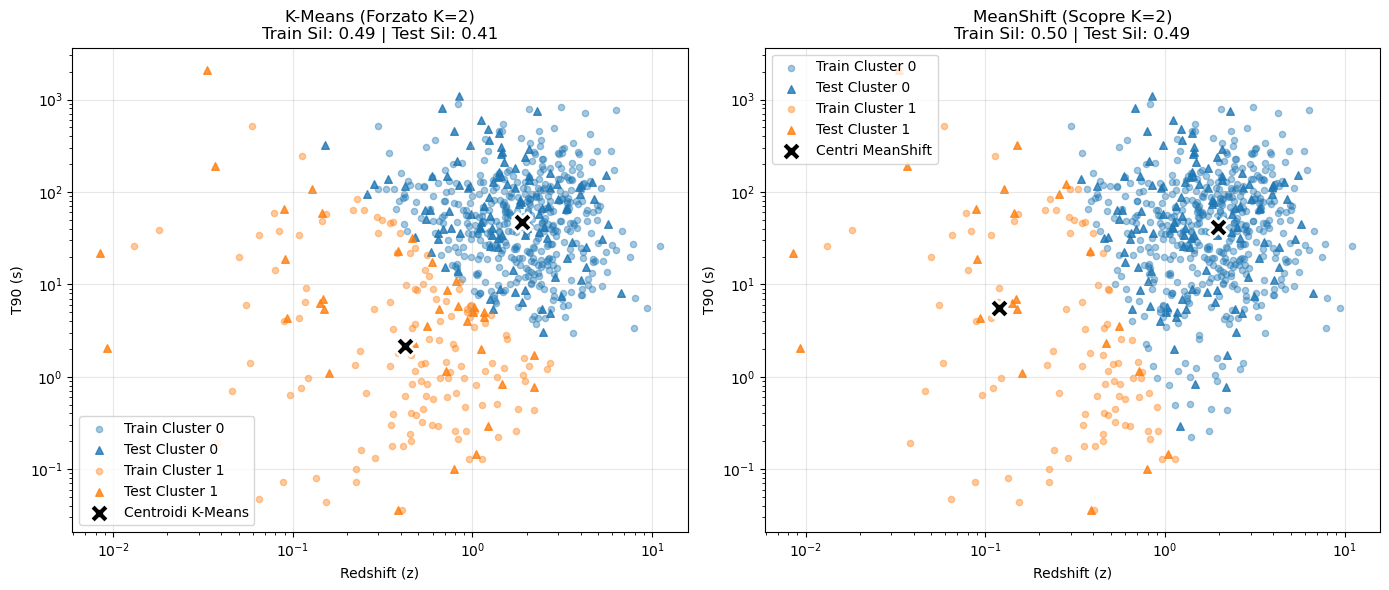

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
colors_palette = ['C0', 'C1', 'C2', 'C3', 'C4']

for ii in range(2):
    ax1.scatter(X_train_raw[labels_km_train==ii, 0], X_train_raw[labels_km_train==ii, 1], 
                color=colors_palette[ii], alpha=0.4, s=20, label=f'Train Cluster {ii}')
    ax1.scatter(X_test_raw[labels_km_test==ii, 0], X_test_raw[labels_km_test==ii, 1], 
                color=colors_palette[ii], marker='^', alpha=0.8, s=30, label=f'Test Cluster {ii}')
ax1.scatter(centri_km_fisici[:, 0], centri_km_fisici[:, 1], 
            marker='X', s=200, color='black', edgecolors='white', linewidths=2, label='Centroidi K-Means')
ax1.set_title(f'K-Means (Forzato K=2)\nTrain Sil: {sil_km_train:.2f} | Test Sil: {sil_km_test:.2f}')
ax1.set_xlabel('Redshift (z)')
ax1.set_ylabel('T90 (s)')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)
ax1.legend()

for ii in range(n_clusters_ms):
    ax2.scatter(X_train_raw[labels_ms_train==ii, 0], X_train_raw[labels_ms_train==ii, 1], 
                color=colors_palette[ii % len(colors_palette)], alpha=0.4, s=20, label=f'Train Cluster {ii}')
    ax2.scatter(X_test_raw[labels_ms_test==ii, 0], X_test_raw[labels_ms_test==ii, 1], 
                color=colors_palette[ii % len(colors_palette)], marker='^', alpha=0.8, s=30, label=f'Test Cluster {ii}')
if n_clusters_ms > 0:
    ax2.scatter(centri_ms_fisici[:, 0], centri_ms_fisici[:, 1], 
                marker='X', s=200, color='black', edgecolors='white', linewidths=2, label='Centri MeanShift')
ax2.set_title(f'MeanShift (Scopre K={n_clusters_ms})\nTrain Sil: {sil_ms_train:.2f} | Test Sil: {sil_ms_test:.2f}')
ax2.set_xlabel('Redshift (z)')
ax2.set_ylabel('T90 (s)')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

#### Definizione dello Score di Silhouette

La **Silhouette** è una metrica di validazione interna per algoritmi di clustering che misura quanto un punto sia simile al proprio cluster (coesione) rispetto agli altri cluster (separazione).

Per ogni punto $i$ del dataset, il coefficiente di Silhouette $s_i$ viene calcolato combinando due distanze medie:
*   **Coesione ($a_i$)**: La distanza media tra il punto $i$ e tutti gli altri punti appartenenti allo **stesso cluster**. Rappresenta la compattezza del gruppo (vogliamo que sia minima).
*   **Separazione ($b_i$)**: La distanza media tra il punto $i$ e tutti i punti del **cluster vicino più prossimo** (ovvero il cluster non suo che è geograficamente più vicino). Rappresenta la distanza dal confine (vogliamo che sia massima).

La formula per il singolo punto $i$ è:
$$s_i = \frac{b_i - a_i}{\max(a_i, b_i)}$$

Lo score di Silhouette globale del dataset è la media aritmetica di tutti i coefficienti $s_i$. Il valore ottenuto oscilla sempre nell'intervallo $[-1, 1]$:
*   **$s \approx +1$**: Ottimo clustering. I punti sono vicini ai membri del proprio gruppo e lontani dagli altri.
*   **$s \approx 0$**: Struttura sovrapposta. I punti giacciono sul confine decisionale tra due o più cluster.
*   **$s \approx -1$**: Clustering errato. I punti sono più vicini a un cluster adiacente rispetto a quello a cui sono stati effettivamente assegnati.

